In [1]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [2]:
#1.
pi = pd.read_csv('GDPCTPI.csv')
unrate = pd.read_csv('UNRATE.csv')
dff = pd.read_csv('DFF.csv')

In [3]:
dff

,observation_date,DFF
0,1959-01-01,2.58
1,1959-04-01,3.08
2,1959-07-01,3.57
3,1959-10-01,3.99
4,1960-01-01,3.93
...,...,...
262,2024-07-01,5.26
263,2024-10-01,4.65
264,2025-01-01,4.33
265,2025-04-01,4.33


In [4]:
df = pd.merge(pi, unrate, on='observation_date', how='inner')
df = pd.merge(df, dff, on='observation_date', how='inner')

In [5]:
df['observation_date'] = pd.to_datetime(df['observation_date'])
df = df.set_index('observation_date')

In [6]:
#2. 
df['inflation_rate'] = 400 * np.log(df['GDPCTPI'] / df['GDPCTPI'].shift(1))

In [7]:
df = df.dropna()

In [8]:
print(df.index.min(), df.index.max())

1959-04-01 00:00:00 2025-04-01 00:00:00


In [9]:
#3.
train_data = df['1960':'2009']
test_data = df['2010':'2024']


--- inflation_rate ---


<Figure size 1000x600 with 0 Axes>

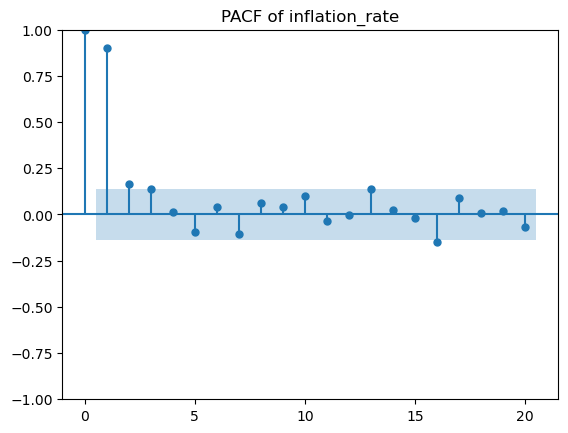


--- UNRATE ---


<Figure size 1000x600 with 0 Axes>

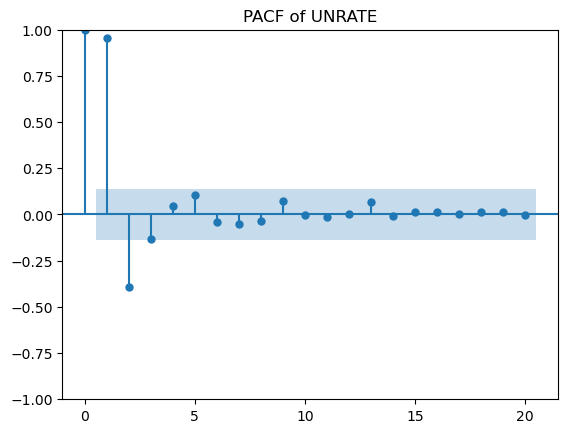


--- DFF ---


<Figure size 1000x600 with 0 Axes>

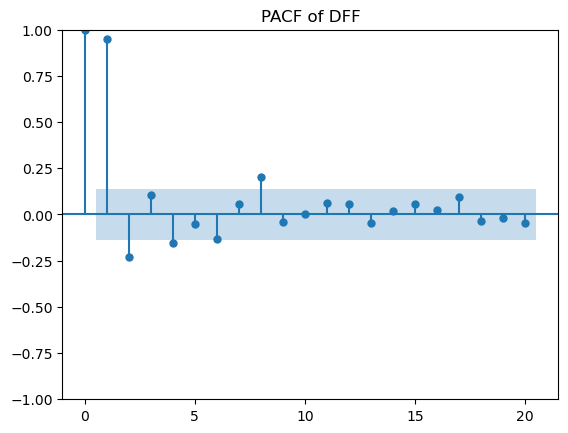

In [10]:
#4.
variables = ['inflation_rate', 'UNRATE', 'DFF']

for var in variables:
    print(f"\n--- {var} ---")
    plt.figure(figsize=(10,6))
    plot_pacf(train_data[var], lags=20)
    plt.title(f"PACF of {var}")
    plt.show()

For all three graphs, the first 3 lags seem the most significant. For the DFF graph the t-9th lag seems significant but it is too far back to be taken into consideration

In [12]:
#5. 
for var in variables:
    sel = ar_select_order(train_data[var], maxlag=20, ic='aic')
    print(f"{var}: selected lags = {sel.ar_lags}")


inflation_rate: selected lags = [1, 2, 3]
UNRATE: selected lags = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
DFF: selected lags = [1, 2, 3, 4, 5, 6, 7, 8]


C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-

The lags don't match completely, the ar_select-order test depicts significance in lags upto t-10 and t-8 for unemployment rate and the Fed Funds Rate which does not match the results from out PACF graph.

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


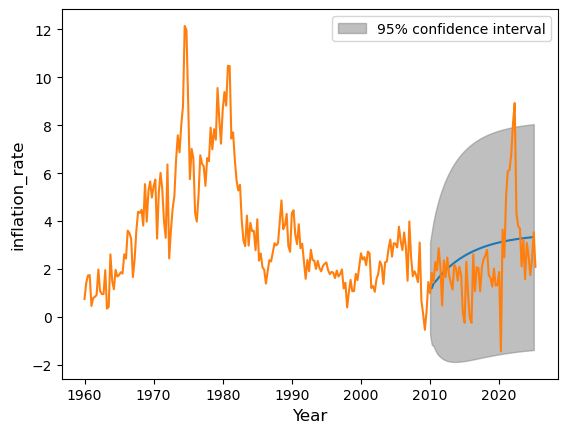

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


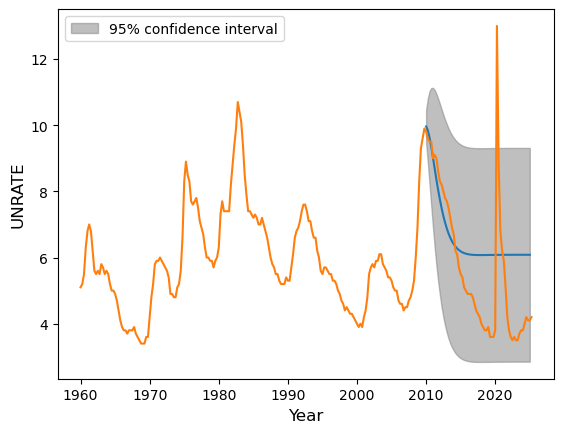

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


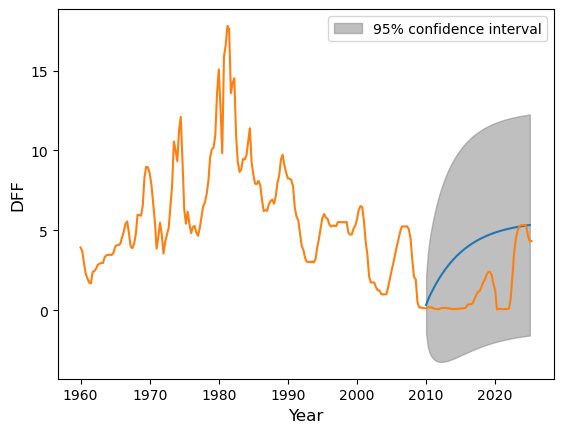

In [14]:
#6
for var in variables:
    model = AutoReg(train_data[var], lags=3)
    model_fit = model.fit()
    forecast = model_fit.predict(start='2010', end='2025')
    
    # Get the axis object from plot_predict
    fig = model_fit.plot_predict(start='2010', end='2025')
    ax = fig.axes[0]  # Get the axis object
    
    # Now you can modify the axis
    plt.plot(df[var]['1960':'2025'])
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(var, fontsize=12)
    plt.show()

The forecasts roughly match the trends of our data. I was hoping for the forcasts to capture more of the volitility. 

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


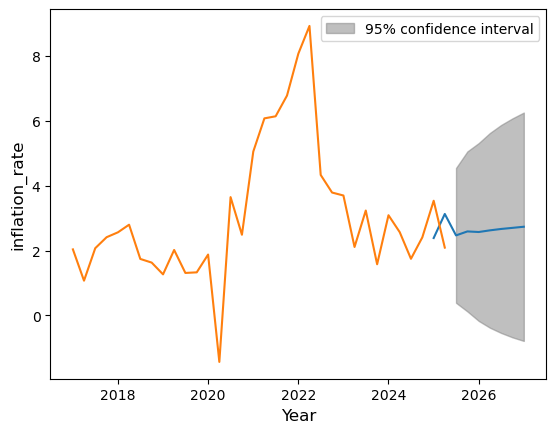

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


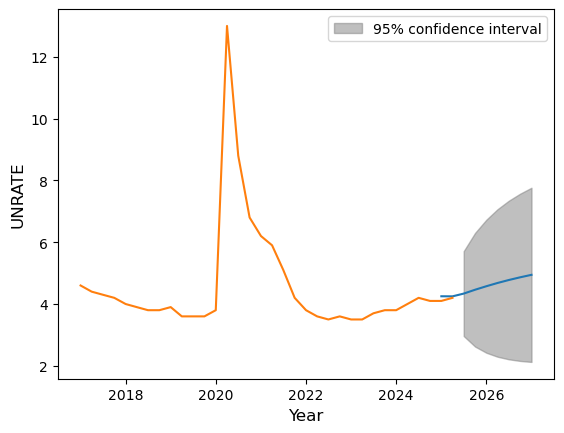

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


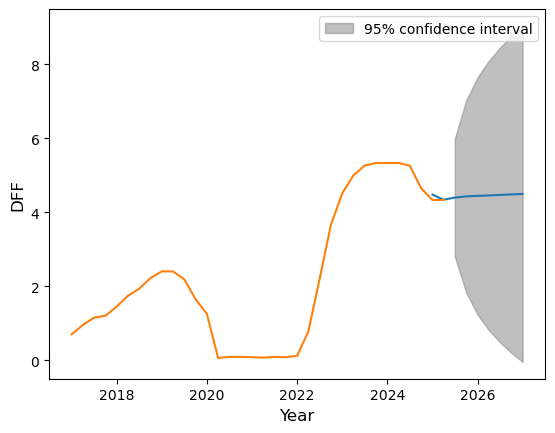

In [16]:
#7.
for var in variables:
    model = AutoReg(df[var], lags=3)
    model_fit = model.fit()
    forecast = model_fit.predict(start='2025', end='2027')
    fig = model_fit.plot_predict(start='2025', end='2027')
    ax = fig.axes[0]  # Get the axis object
    plt.plot(df[var]['2017':'2027'])
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel(var, fontsize=12)
    plt.show()

The forecasts seem to follow the trends from 2025 data. I am not very confident about this given that they do not capture volitility 

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


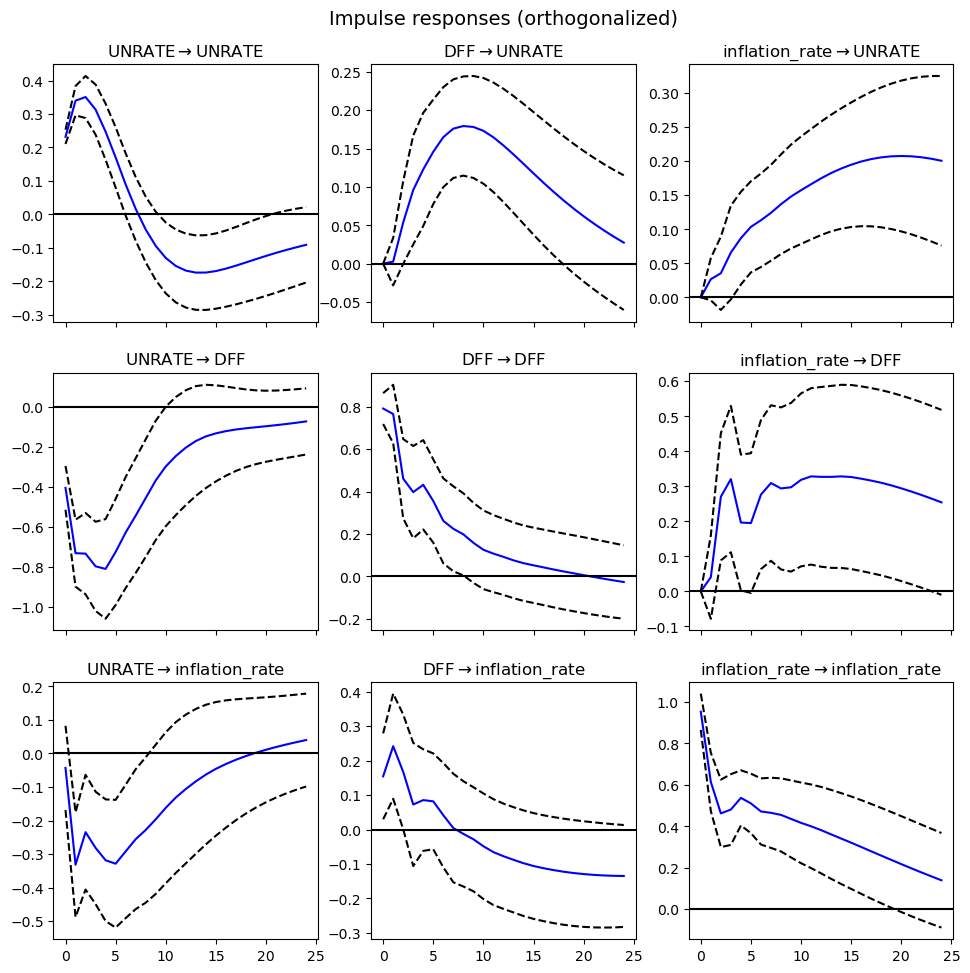

In [18]:
#8.
sample = df['1960':'2000']
sample = sample.drop('GDPCTPI', axis=1)
model = VAR(sample)
results = model.fit(4)
irf = results.irf(24)
fig = irf.plot(orth=True,signif=0.1) #level price level out

In [19]:
#9. 
fevd = results.fevd(12)
fevd.summary()

FEVD for UNRATE
        UNRATE       DFF  inflation_rate
0     1.000000  0.000000        0.000000
1     0.995773  0.000043        0.004184
2     0.983647  0.009744        0.006609
3     0.954918  0.029675        0.015408
4     0.916520  0.055329        0.028151
5     0.867849  0.087694        0.044456
6     0.811842  0.125927        0.062231
7     0.753787  0.164654        0.081560
8     0.699754  0.198127        0.102119
9     0.654048  0.223480        0.122472
10    0.618180  0.240189        0.141631
11    0.591042  0.249247        0.159710

FEVD for DFF
        UNRATE       DFF  inflation_rate
0     0.207330  0.792670        0.000000
1     0.365278  0.633865        0.000857
2     0.452053  0.520692        0.027255
3     0.515465  0.435713        0.048822
4     0.560205  0.391942        0.047853
5     0.586945  0.364241        0.048814
6     0.600493  0.341973        0.057534
7     0.605385  0.325720        0.068895
8     0.606265  0.315105        0.078630
9     0.603948  0.307251   

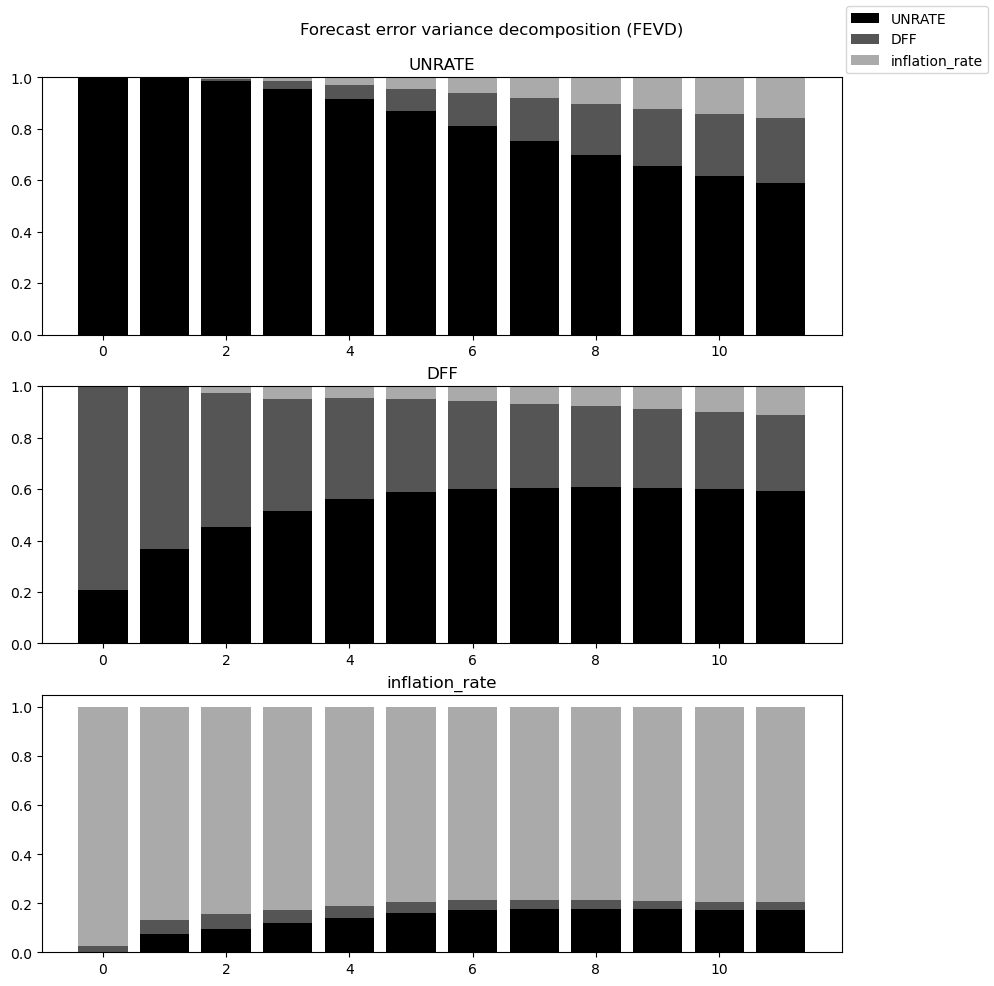

In [20]:
fevd.plot();

In [81]:
# Perform Granger causality tests for all variable pairs
for target_var in sample.columns:
    for cause_var in [v for v in sample.columns if v != target_var]:
        test_result = results.test_causality(target_var, [cause_var], kind='f')
        print(f"Granger Causality Test: Does {cause_var} cause {target_var}?")
        print(test_result.summary())
        print("P-value:", test_result.pvalue, "\n")

Granger Causality Test: Does DFF cause UNRATE?
Granger causality F-test. H_0: DFF does not Granger-cause UNRATE. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         4.369          2.392   0.002 (4, 441)
----------------------------------------------
P-value: 0.00178644695913775 

Granger Causality Test: Does inflation_rate cause UNRATE?
Granger causality F-test. H_0: inflation_rate does not Granger-cause UNRATE. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.9731          2.392   0.422 (4, 441)
----------------------------------------------
P-value: 0.42192845180542493 

Granger Causality Test: Does UNRATE cause DFF?
Granger causality F-test. H_0: UNRATE does not Granger-cause DFF. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   

In [33]:
#11.

C:\Users\tanis\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


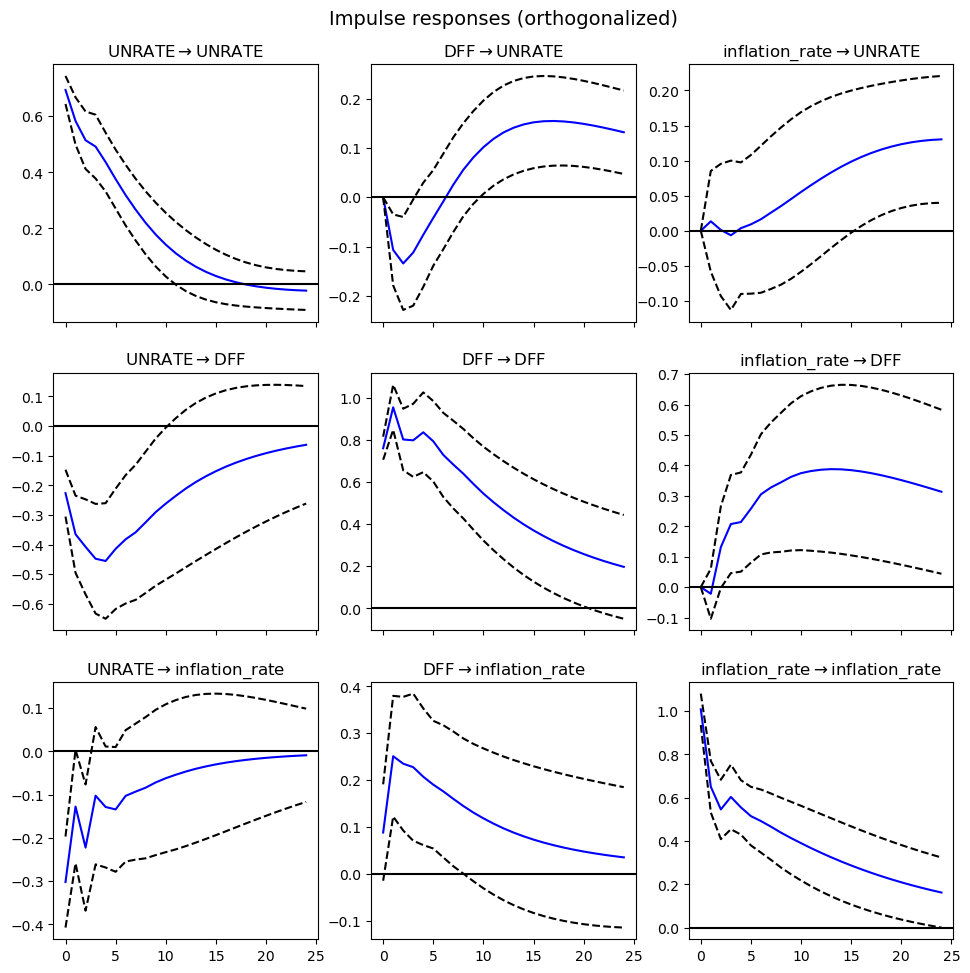

In [34]:
#8.
df2 = df.drop('GDPCTPI', axis=1)
modelDF = VAR(df2)
resultsDF = modelDF.fit(4)
irfDF = resultsDF.irf(24)
figDF = irfDF.plot(orth=True,signif=0.1)

In [36]:
#9. 
fevdDF = resultsDF.fevd(12)
fevdDF.summary()

FEVD for UNRATE
        UNRATE       DFF  inflation_rate
0     1.000000  0.000000        0.000000
1     0.986071  0.013711        0.000217
2     0.973423  0.026414        0.000163
3     0.969149  0.030687        0.000163
4     0.969297  0.030552        0.000152
5     0.970790  0.029022        0.000188
6     0.972241  0.027431        0.000327
7     0.972608  0.026722        0.000670
8     0.971102  0.027606        0.001292
9     0.967356  0.030344        0.002300
10    0.961254  0.034960        0.003786
11    0.952900  0.041296        0.005804

FEVD for DFF
        UNRATE       DFF  inflation_rate
0     0.081636  0.918364        0.000000
1     0.110364  0.889355        0.000280
2     0.140408  0.852485        0.007108
3     0.163198  0.818819        0.017983
4     0.175225  0.800183        0.024592
5     0.179028  0.787694        0.033278
6     0.180421  0.774998        0.044580
7     0.180712  0.763305        0.055984
8     0.179494  0.753111        0.067395
9     0.177330  0.743421   

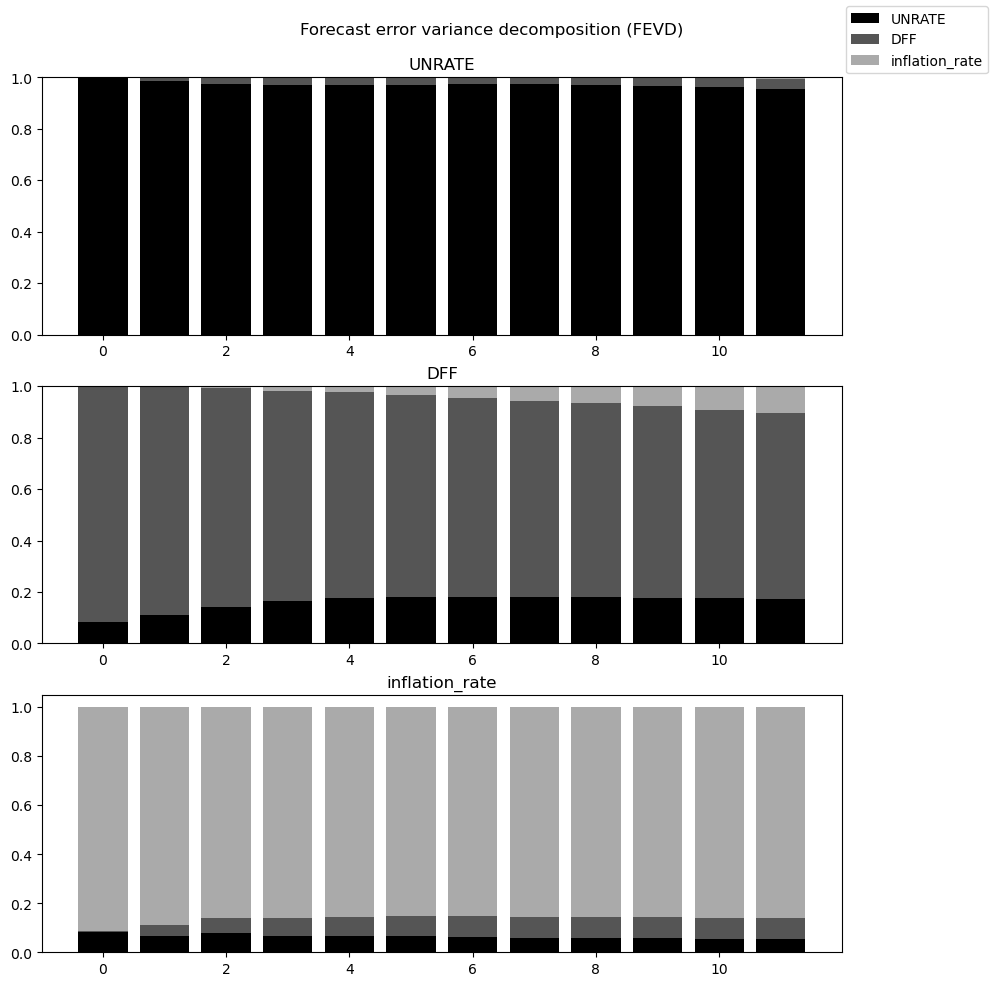

In [38]:
fevdDF.plot();

In [87]:
# Perform Granger causality tests for all variable pairs
for target_var in df2.columns:
    for cause_var in [v for v in df2.columns if v != target_var]:
        test_result = resultsDF.test_causality(target_var, [cause_var], kind='f')
        print(f"Granger Causality Test: Does {cause_var} cause {target_var}?")
        print(test_result.summary())
        print("P-value:", test_result.pvalue, "\n")

Granger Causality Test: Does DFF cause UNRATE?
Granger causality F-test. H_0: DFF does not Granger-cause UNRATE. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
         3.188          2.384   0.013 (4, 744)
----------------------------------------------
P-value: 0.01305245553124593 

Granger Causality Test: Does inflation_rate cause UNRATE?
Granger causality F-test. H_0: inflation_rate does not Granger-cause UNRATE. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.2715          2.384   0.896 (4, 744)
----------------------------------------------
P-value: 0.8963896682777714 

Granger Causality Test: Does UNRATE cause DFF?
Granger causality F-test. H_0: UNRATE does not Granger-cause DFF. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value  

In [39]:
#10. 
resultsDF.test_causality('inflation_rate', ['UNRATE'], kind='f').summary()

Test statistic,Critical value,p-value,df
1.707,2.384,0.146,"(4, 744)"


In [40]:
#10. 
resultsDF.test_causality('DFF', ['UNRATE'], kind='f').summary()

Test statistic,Critical value,p-value,df
0.9899,2.384,0.412,"(4, 744)"


In [42]:
#10. 
resultsDF.test_causality('inflation_rate', ['DFF'], kind='f').summary()

Test statistic,Critical value,p-value,df
2.463,2.384,0.044,"(4, 744)"
